In [ ]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.models import load_model

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             r2_score)

import os, json, zipfile, pickle
from datetime import datetime

In [ ]:
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("✅ Download Complete!")
print(f"📁 Path: {path}")

import glob
csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
print(f"\n📄 CSV Files Found: {len(csv_files)}")
for f in csv_files:
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f"   {os.path.basename(f):<40} ({size_mb:.1f} MB)")

100%|██████████| 11.4M/11.4M [00:00<00:00, 78.6MB/s]

Extracting files...


✅ Download Complete!
📁 Path: /root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3

📄 CSV Files Found: 13
   DAYTON_hourly.csv                        (3.1 MB)
   AEP_hourly.csv                           (3.2 MB)
   FE_hourly.csv                            (1.6 MB)
   DEOK_hourly.csv                          (1.5 MB)
   PJMW_hourly.csv                          (3.7 MB)
   PJM_Load_hourly.csv                      (0.9 MB)
   pjm_hourly_est.csv                       (12.1 MB)
   DOM_hourly.csv                           (3.1 MB)
   PJME_hourly.csv                          (3.9 MB)
   DUQ_hourly.csv                           (3.1 MB)
   COMED_hourly.csv                         (1.8 MB)
   NI_hourly.csv                            (1.5 MB)
   EKPC_hourly.csv                          (1.2 MB)


In [ ]:
# AEP_hourly.csv load করো (largest & cleanest file)
target_file = None
for f in csv_files:
    if 'AEP_hourly' in f:
        target_file = f
        break

# না পেলে সবচেয়ে বড় file নাও
if target_file is None:
    target_file = max(csv_files, key=os.path.getsize)

print(f"📄 Loading: {os.path.basename(target_file)}")

df = pd.read_csv(target_file)

print(f"\n✅ Dataset Loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
print(f"\n🔍 First 5 Rows:")
display(df.head())

print(f"\n📊 Basic Info:")
print(f"   Total Rows    : {df.shape[0]:,}")
print(f"   Total Columns : {df.shape[1]}")
print(f"\n📊 Data Types:")
print(df.dtypes.to_string())

📄 Loading: AEP_hourly.csv

✅ Dataset Loaded!
   Shape   : (121273, 2)
   Columns : ['Datetime', 'AEP_MW']

🔍 First 5 Rows:


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0



📊 Basic Info:
   Total Rows    : 121,273
   Total Columns : 2

📊 Data Types:
Datetime     object
AEP_MW      float64


In [ ]:
# --- 4.1 Column Rename ---
print("\n📌 Step 1: Column Setup...")
df.columns = ['Datetime', 'Energy_MW']
print(f"   Columns Renamed : {list(df.columns)}")


📌 Step 1: Column Setup...
   Columns Renamed : ['Datetime', 'Energy_MW']


In [ ]:
# --- 4.2 Parse Datetime ---
print("\n📌 Step 2: Parsing Datetime...")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"   Date Range : {df['Datetime'].min()} → {df['Datetime'].max()}")
print(f"   Total Hours: {len(df):,}")


📌 Step 2: Parsing Datetime...
   Date Range : 2004-10-01 01:00:00 → 2018-08-03 00:00:00
   Total Hours: 121,273


In [ ]:
# --- 4.3 Missing Values ---
print("\n📌 Step 3: Missing Values Check...")
missing = df.isnull().sum()
print(f"   Datetime   Null : {missing['Datetime']}")
print(f"   Energy_MW  Null : {missing['Energy_MW']}")

if missing['Energy_MW'] > 0:
    df['Energy_MW'] = df['Energy_MW'].interpolate(method='linear')
    print(f"   ✅ Interpolated {missing['Energy_MW']} missing values")
else:
    print("   ✅ No Missing Values!")


📌 Step 3: Missing Values Check...
   Datetime   Null : 0
   Energy_MW  Null : 0
   ✅ No Missing Values!


In [ ]:
# --- 4.4 Duplicate Check ---
print("\n📌 Step 4: Duplicate Check...")
dups = df.duplicated(subset=['Datetime']).sum()
print(f"   Duplicate Timestamps : {dups}")
if dups > 0:
    df.drop_duplicates(subset=['Datetime'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   ✅ Removed {dups} duplicates")


📌 Step 4: Duplicate Check...
   Duplicate Timestamps : 4
   ✅ Removed 4 duplicates


In [ ]:
# --- 4.5 Negative / Zero Values ---
print("\n📌 Step 5: Invalid Values Check...")
neg_count  = (df['Energy_MW'] <= 0).sum()
print(f"   Negative/Zero Values : {neg_count}")
if neg_count > 0:
    median_val = df['Energy_MW'].median()
    df.loc[df['Energy_MW'] <= 0, 'Energy_MW'] = median_val
    print(f"   ✅ Replaced with median ({median_val:.2f})")


📌 Step 5: Invalid Values Check...
   Negative/Zero Values : 0


In [ ]:
# --- 4.6 Outlier Check (IQR) ---
print("\n📌 Step 6: Outlier Detection (IQR)...")
Q1  = df['Energy_MW'].quantile(0.25)
Q3  = df['Energy_MW'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3.0 * IQR
upper = Q3 + 3.0 * IQR
outliers = ((df['Energy_MW'] < lower) |
            (df['Energy_MW'] > upper)).sum()
print(f"   Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR:.1f}")
print(f"   Lower Bound : {lower:.1f}")
print(f"   Upper Bound : {upper:.1f}")
print(f"   Outliers    : {outliers}")

# Clip outliers
df['Energy_MW'] = df['Energy_MW'].clip(lower=lower, upper=upper)
print(f"   ✅ Outliers clipped to bounds")


📌 Step 6: Outlier Detection (IQR)...
   Q1=13630.0 | Q3=17200.0 | IQR=3570.0
   Lower Bound : 2920.0
   Upper Bound : 27910.0
   Outliers    : 0
   ✅ Outliers clipped to bounds


In [ ]:
# --- 4.7 Stats After Cleaning ---
print("\n📊 Energy_MW Stats After Cleaning:")
print(f"   Min    : {df['Energy_MW'].min():.2f} MW")
print(f"   Max    : {df['Energy_MW'].max():.2f} MW")
print(f"   Mean   : {df['Energy_MW'].mean():.2f} MW")
print(f"   Std    : {df['Energy_MW'].std():.2f} MW")
print(f"   Median : {df['Energy_MW'].median():.2f} MW")


📊 Energy_MW Stats After Cleaning:
   Min    : 9581.00 MW
   Max    : 25695.00 MW
   Mean   : 15499.65 MW
   Std    : 2591.32 MW
   Median : 15310.00 MW


In [ ]:
df_feat = df.copy()

# --- Time Features ---
print("\n📌 Time-Based Features...")
df_feat['Hour']       = df_feat['Datetime'].dt.hour
df_feat['DayOfWeek']  = df_feat['Datetime'].dt.dayofweek
df_feat['Month']      = df_feat['Datetime'].dt.month
df_feat['Year']       = df_feat['Datetime'].dt.year
df_feat['DayOfYear']  = df_feat['Datetime'].dt.dayofyear
df_feat['Quarter']    = df_feat['Datetime'].dt.quarter
df_feat['WeekOfYear'] = df_feat['Datetime'].dt.isocalendar().week.astype(int)
df_feat['IsWeekend']  = (df_feat['DayOfWeek'] >= 5).astype(int)
print("   Hour | DayOfWeek | Month | Year | DayOfYear")
print("   Quarter | WeekOfYear | IsWeekend  ✅")

# --- Cyclical Encoding (sin/cos) ---
print("\n📌 Cyclical Encoding (sin/cos)...")
df_feat['Hour_sin']  = np.sin(2 * np.pi * df_feat['Hour'] / 24)
df_feat['Hour_cos']  = np.cos(2 * np.pi * df_feat['Hour'] / 24)
df_feat['Month_sin'] = np.sin(2 * np.pi * df_feat['Month'] / 12)
df_feat['Month_cos'] = np.cos(2 * np.pi * df_feat['Month'] / 12)
df_feat['DOW_sin']   = np.sin(2 * np.pi * df_feat['DayOfWeek'] / 7)
df_feat['DOW_cos']   = np.cos(2 * np.pi * df_feat['DayOfWeek'] / 7)
print("   Hour sin/cos | Month sin/cos | DayOfWeek sin/cos  ✅")

# --- Lag Features ---
print("\n📌 Lag Features...")
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df_feat[f'lag_{lag}h'] = df_feat['Energy_MW'].shift(lag)
    print(f"   lag_{lag}h added")

# --- Rolling Statistics ---
print("\n📌 Rolling Statistics...")
for window in [6, 12, 24, 168]:
    df_feat[f'roll_mean_{window}h'] = (
        df_feat['Energy_MW'].rolling(window).mean())
    df_feat[f'roll_std_{window}h'] = (
        df_feat['Energy_MW'].rolling(window).std())
    df_feat[f'roll_max_{window}h'] = (
        df_feat['Energy_MW'].rolling(window).max())
    df_feat[f'roll_min_{window}h'] = (
        df_feat['Energy_MW'].rolling(window).min())
    print(f"   mean/std/max/min ({window}h window) added")

# Drop NaN rows
before = len(df_feat)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)
after = len(df_feat)

print(f"\n✅ Feature Engineering Done!")
print(f"   Rows Before : {before:,}")
print(f"   Rows After  : {after:,}  (dropped {before-after} NaN rows)")
print(f"   Total Features : {df_feat.shape[1]-2}")


📌 Time-Based Features...
   Hour | DayOfWeek | Month | Year | DayOfYear
   Quarter | WeekOfYear | IsWeekend  ✅

📌 Cyclical Encoding (sin/cos)...
   Hour sin/cos | Month sin/cos | DayOfWeek sin/cos  ✅

📌 Lag Features...
   lag_1h added
   lag_2h added
   lag_3h added
   lag_6h added
   lag_12h added
   lag_24h added
   lag_48h added
   lag_168h added

📌 Rolling Statistics...
   mean/std/max/min (6h window) added
   mean/std/max/min (12h window) added
   mean/std/max/min (24h window) added
   mean/std/max/min (168h window) added

✅ Feature Engineering Done!
   Rows Before : 121,269
   Rows After  : 121,101  (dropped 168 NaN rows)
   Total Features : 38


In [ ]:
# --- 6.1 Select Feature Columns ---
print("\n📌 Step 1: Feature Selection...")
drop_cols    = ['Datetime', 'Energy_MW']
feature_cols = [c for c in df_feat.columns
                if c not in drop_cols]

print(f"   Total Features : {len(feature_cols)}")
for i, f in enumerate(feature_cols):
    print(f"   {i+1:2}. {f}")

X_raw = df_feat[feature_cols].values
y_raw = df_feat['Energy_MW'].values


📌 Step 1: Feature Selection...
   Total Features : 38
    1. Hour
    2. DayOfWeek
    3. Month
    4. Year
    5. DayOfYear
    6. Quarter
    7. WeekOfYear
    8. IsWeekend
    9. Hour_sin
   10. Hour_cos
   11. Month_sin
   12. Month_cos
   13. DOW_sin
   14. DOW_cos
   15. lag_1h
   16. lag_2h
   17. lag_3h
   18. lag_6h
   19. lag_12h
   20. lag_24h
   21. lag_48h
   22. lag_168h
   23. roll_mean_6h
   24. roll_std_6h
   25. roll_max_6h
   26. roll_min_6h
   27. roll_mean_12h
   28. roll_std_12h
   29. roll_max_12h
   30. roll_min_12h
   31. roll_mean_24h
   32. roll_std_24h
   33. roll_max_24h
   34. roll_min_24h
   35. roll_mean_168h
   36. roll_std_168h
   37. roll_max_168h
   38. roll_min_168h


In [ ]:
# --- 6.2 Normalize ---
print("\n📌 Step 2: Normalizing (MinMaxScaler 0→1)...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(
    y_raw.reshape(-1, 1)).flatten()

print(f"   X: [{X_raw.min():.1f}, {X_raw.max():.1f}] "
      f"→ [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"   y: [{y_raw.min():.1f}, {y_raw.max():.1f}] "
      f"→ [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")


📌 Step 2: Normalizing (MinMaxScaler 0→1)...
   X: [-1.0, 25695.0] → [0.00, 1.00]
   y: [9581.0, 25695.0] → [0.00, 1.00]


In [ ]:
# --- 6.3 Create LSTM Sequences ---
print("\n📌 Step 3: Creating LSTM Sequences...")
SEQ_LEN = 24  # 24-hour look-back window

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i: i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

print(f"   Sequence Length : {SEQ_LEN} hours (look-back)")
print(f"   X Shape         : {X_seq.shape}")
print(f"     → (samples, timesteps, features)")
print(f"   y Shape         : {y_seq.shape}")


📌 Step 3: Creating LSTM Sequences...
   Sequence Length : 24 hours (look-back)
   X Shape         : (121077, 24, 38)
     → (samples, timesteps, features)
   y Shape         : (121077,)


In [ ]:
# --- 6.4 Time-Based Split (70/15/15) ---
print("\n📌 Step 4: Time-Based Train/Val/Test Split...")
n         = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]
X_val   = X_seq[train_end:val_end]
y_val   = y_seq[train_end:val_end]
X_test  = X_seq[val_end:]
y_test  = y_seq[val_end:]

print(f"   Train : {X_train.shape[0]:,}  (70%)")
print(f"   Val   : {X_val.shape[0]:,}   (15%)")
print(f"   Test  : {X_test.shape[0]:,}   (15%)")



📌 Step 4: Time-Based Train/Val/Test Split...
   Train : 84,753  (70%)
   Val   : 18,162   (15%)
   Test  : 18,162   (15%)


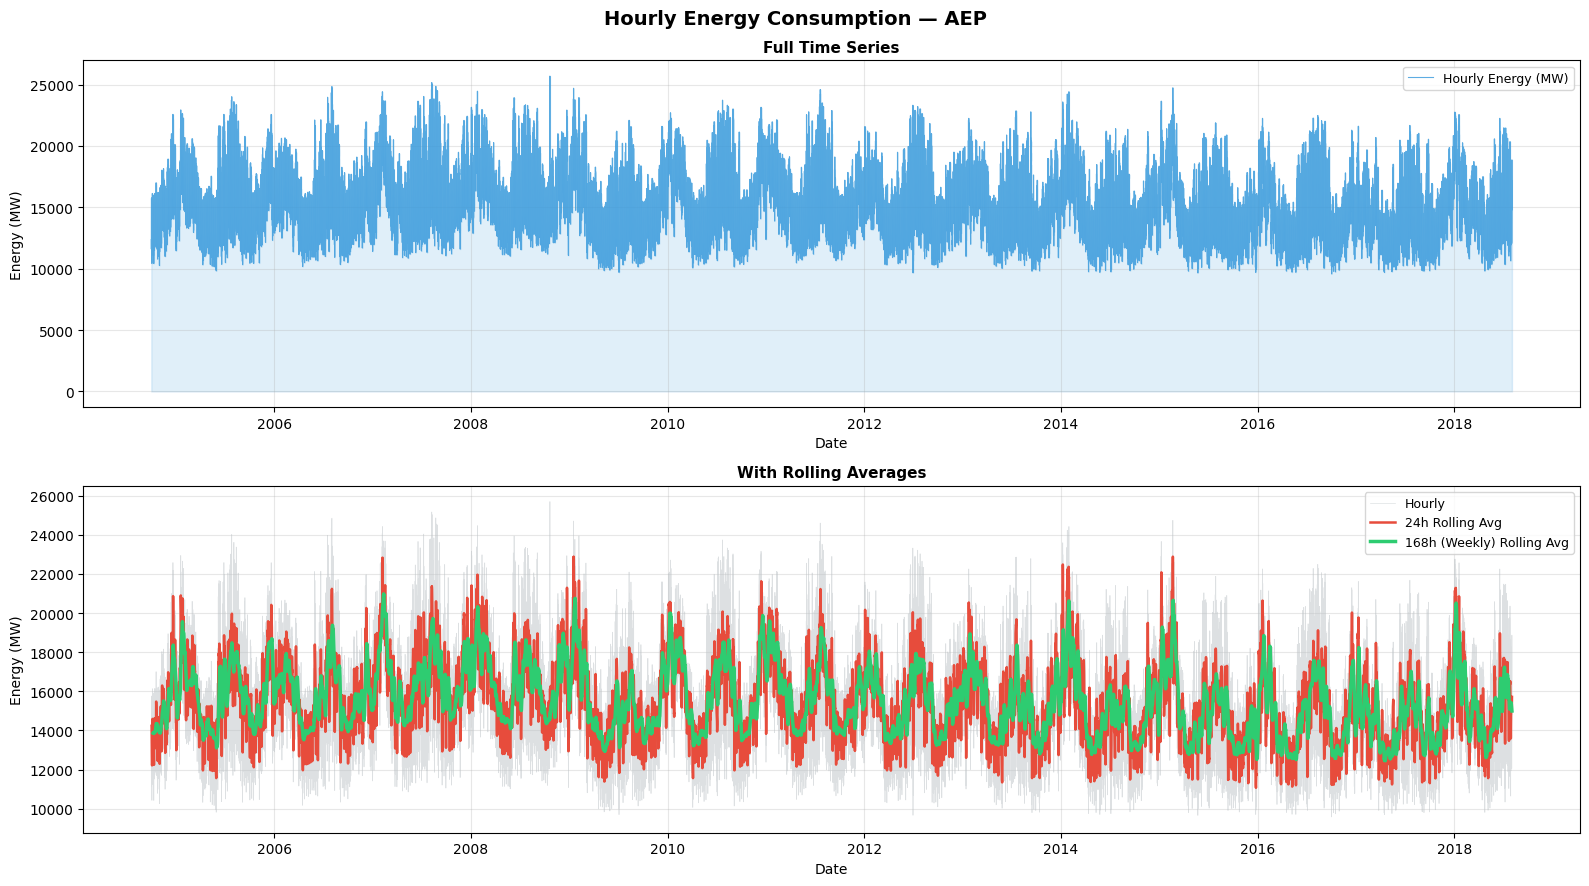

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Hourly Energy Consumption — AEP',
             fontsize=14, fontweight='bold')

# Full Series
axes[0].plot(df['Datetime'], df['Energy_MW'],
             color='#3498db', lw=0.8, alpha=0.8,
             label='Hourly Energy (MW)')
axes[0].fill_between(df['Datetime'], df['Energy_MW'],
                     alpha=0.15, color='#3498db')
axes[0].set_title('Full Time Series', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Energy (MW)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Rolling Average
roll_24  = df['Energy_MW'].rolling(24).mean()
roll_168 = df['Energy_MW'].rolling(168).mean()

axes[1].plot(df['Datetime'], df['Energy_MW'],
             color='#bdc3c7', lw=0.5, alpha=0.5, label='Hourly')
axes[1].plot(df['Datetime'], roll_24,
             color='#e74c3c', lw=1.8,
             label='24h Rolling Avg')
axes[1].plot(df['Datetime'], roll_168,
             color='#2ecc71', lw=2.5,
             label='168h (Weekly) Rolling Avg')
axes[1].set_title('With Rolling Averages',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Energy (MW)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()

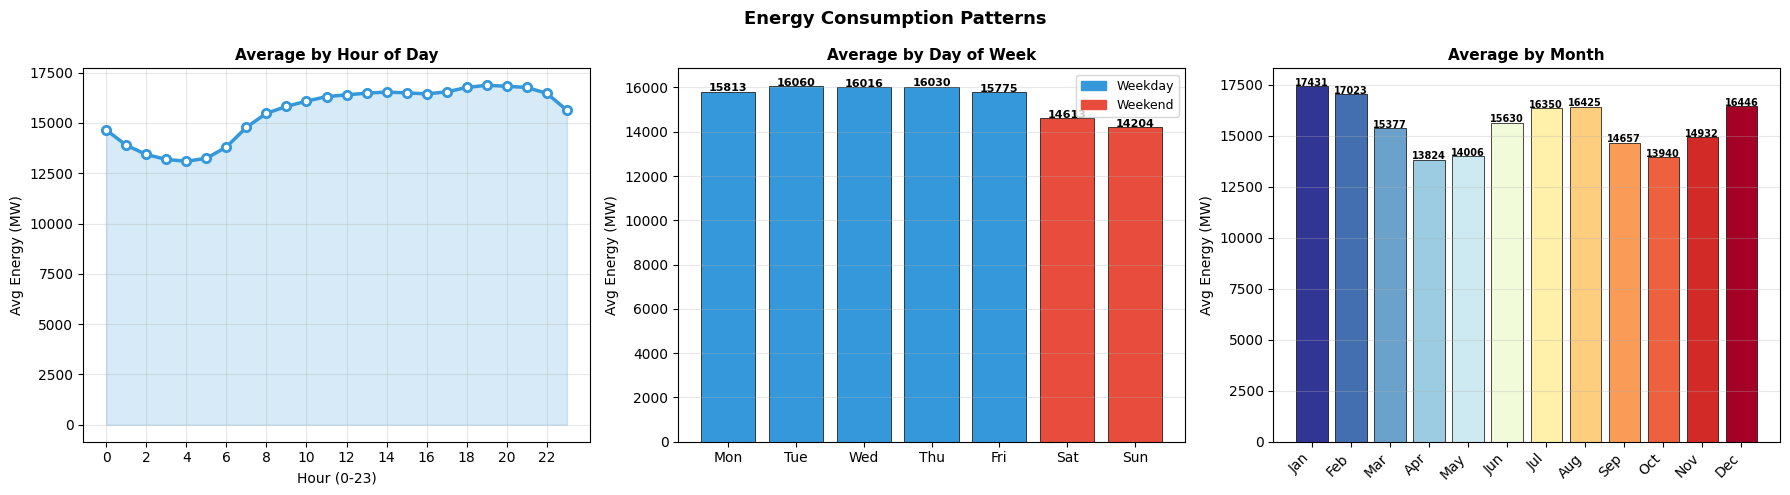

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Energy Consumption Patterns',
             fontsize=13, fontweight='bold')

# Hourly Pattern
hourly_avg = df_feat.groupby('Hour')['Energy_MW'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values,
             '-o', color='#3498db', lw=2.5, ms=6,
             markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values,
                     alpha=0.2, color='#3498db')
axes[0].set_title('Average by Hour of Day',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Avg Energy (MW)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(alpha=0.3)

# Daily Pattern (Day of Week)
dow_avg   = df_feat.groupby('DayOfWeek')['Energy_MW'].mean()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors_d  = ['#3498db']*5 + ['#e74c3c']*2
bars = axes[1].bar(dow_names, dow_avg.values,
                   color=colors_d,
                   edgecolor='black', lw=0.5)
for bar, val in zip(bars, dow_avg.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20,
                 f'{val:.0f}', ha='center',
                 fontsize=8, fontweight='bold')
axes[1].set_title('Average by Day of Week',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg Energy (MW)')
axes[1].grid(axis='y', alpha=0.3)
wkday = mpatches.Patch(color='#3498db', label='Weekday')
wkend = mpatches.Patch(color='#e74c3c', label='Weekend')
axes[1].legend(handles=[wkday, wkend], fontsize=9)

# Monthly Pattern
month_avg   = df_feat.groupby('Month')['Energy_MW'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
colors_m = plt.cm.RdYlBu_r(np.linspace(0, 1, 12))
bars2 = axes[2].bar(month_names, month_avg.values,
                    color=colors_m,
                    edgecolor='black', lw=0.5)
for bar, val in zip(bars2, month_avg.values):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+20,
                 f'{val:.0f}', ha='center',
                 fontsize=7, fontweight='bold')
axes[2].set_title('Average by Month',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Avg Energy (MW)')
axes[2].set_xticklabels(month_names, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_seasonal_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

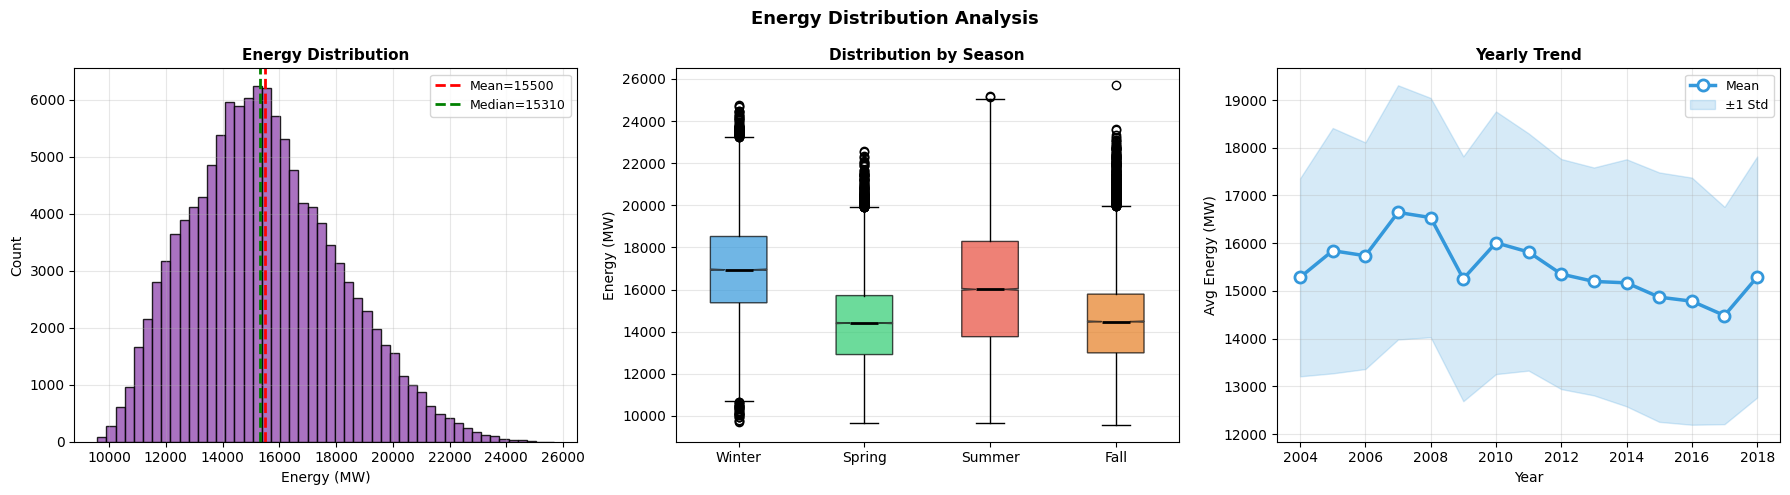

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Energy Distribution Analysis',
             fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(df['Energy_MW'], bins=50,
             color='#9b59b6', edgecolor='black',
             lw=0.4, alpha=0.85)
axes[0].axvline(df['Energy_MW'].mean(), color='red',
                ls='--', lw=2,
                label=f"Mean={df['Energy_MW'].mean():.0f}")
axes[0].axvline(df['Energy_MW'].median(), color='green',
                ls='--', lw=2,
                label=f"Median={df['Energy_MW'].median():.0f}")
axes[0].set_title('Energy Distribution',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Energy (MW)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Box Plot by Season
df_feat['Season'] = df_feat['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Fall',10:'Fall',11:'Fall'
})
season_order  = ['Winter','Spring','Summer','Fall']
season_colors = ['#3498db','#2ecc71','#e74c3c','#e67e22']
season_data   = [df_feat[df_feat['Season']==s]['Energy_MW'].values
                 for s in season_order]

bp = axes[1].boxplot(season_data, labels=season_order,
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
axes[1].set_title('Distribution by Season',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Energy (MW)')
axes[1].grid(axis='y', alpha=0.3)

# Yearly Trend
yearly = df_feat.groupby('Year')['Energy_MW'].agg(
    ['mean','std']).reset_index()
axes[2].plot(yearly['Year'], yearly['mean'],
             '-o', color='#3498db', lw=2.5,
             ms=8, markerfacecolor='white',
             markeredgewidth=2, label='Mean')
axes[2].fill_between(
    yearly['Year'],
    yearly['mean'] - yearly['std'],
    yearly['mean'] + yearly['std'],
    alpha=0.2, color='#3498db', label='±1 Std'
)
axes[2].set_title('Yearly Trend',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg Energy (MW)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_distribution_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

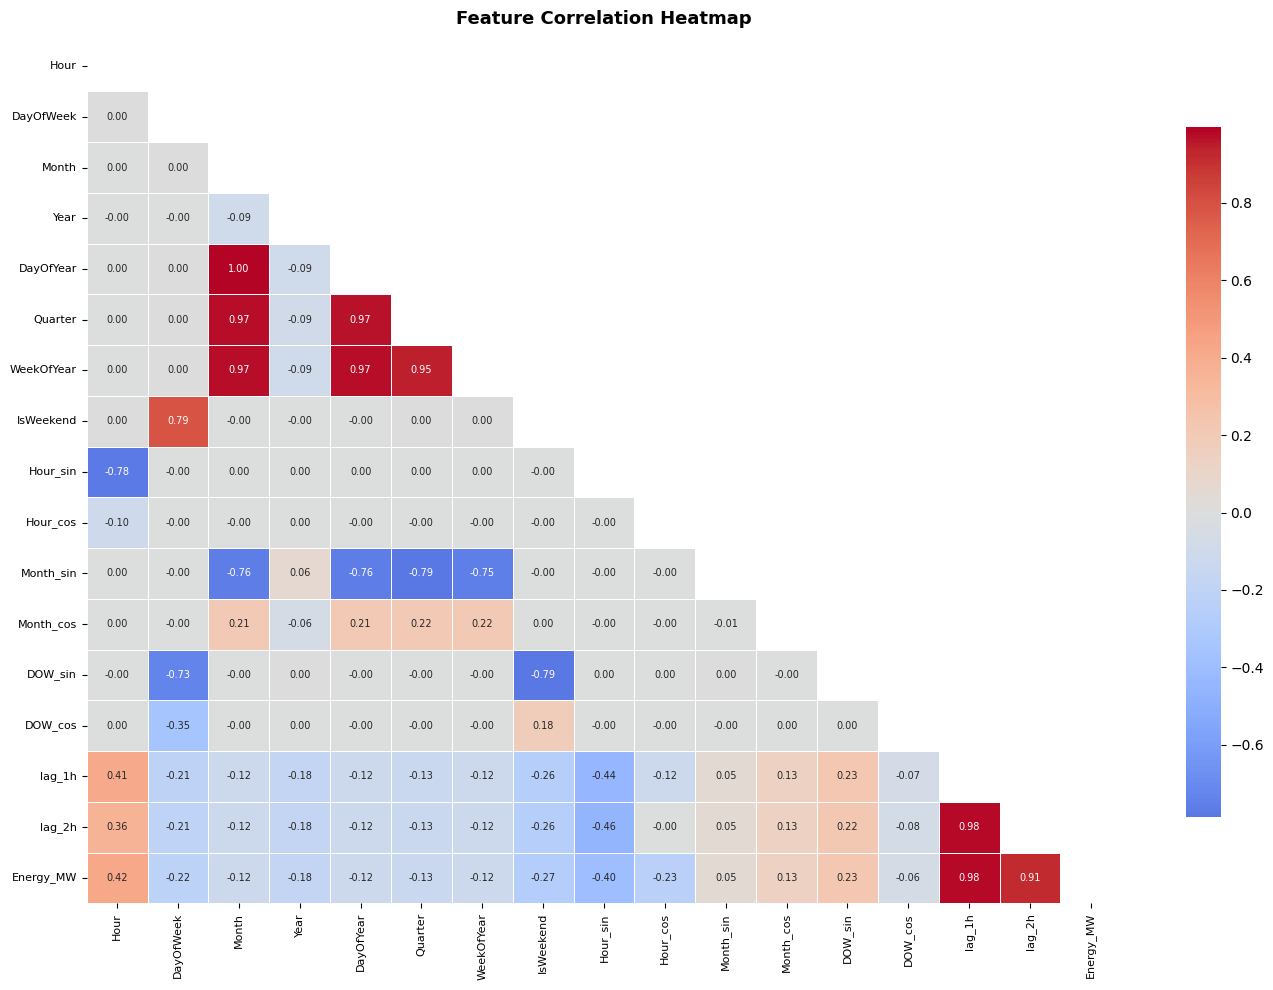

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_cols = feature_cols[:16] + ['Energy_MW']
corr_mat  = df_feat[corr_cols].corr()
mask      = np.triu(np.ones_like(corr_mat, dtype=bool))

sns.heatmap(
    corr_mat, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

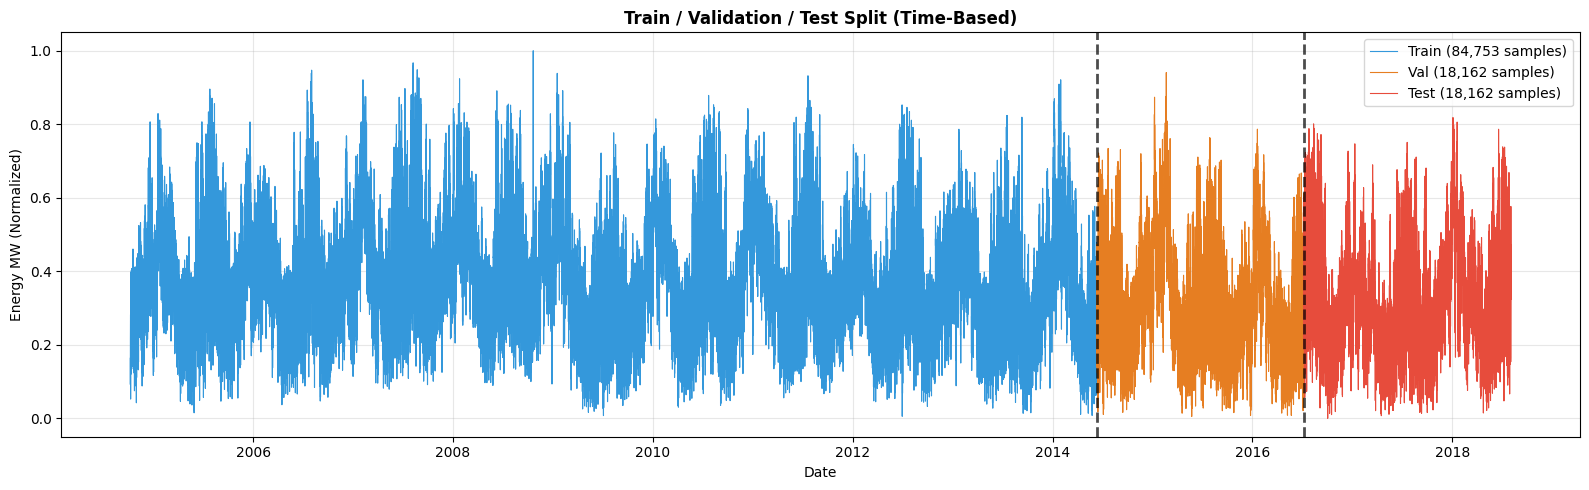

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

dates   = df_feat['Datetime'].values[SEQ_LEN:]
n_total = len(dates)
t_end   = int(n_total * 0.70)
v_end   = int(n_total * 0.85)

ax.plot(dates[:t_end],
        y_seq[:t_end],
        color='#3498db', lw=0.8,
        label=f'Train ({t_end:,} samples)')
ax.plot(dates[t_end:v_end],
        y_seq[t_end:v_end],
        color='#e67e22', lw=0.8,
        label=f'Val ({v_end-t_end:,} samples)')
ax.plot(dates[v_end:],
        y_seq[v_end:],
        color='#e74c3c', lw=0.8,
        label=f'Test ({n_total-v_end:,} samples)')

ax.axvline(dates[t_end], color='black',
           ls='--', lw=2, alpha=0.7)
ax.axvline(dates[v_end], color='black',
           ls='--', lw=2, alpha=0.7)
ax.set_title('Train / Validation / Test Split (Time-Based)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy MW (Normalized)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('05_data_split.png', dpi=120, bbox_inches='tight')
plt.show()

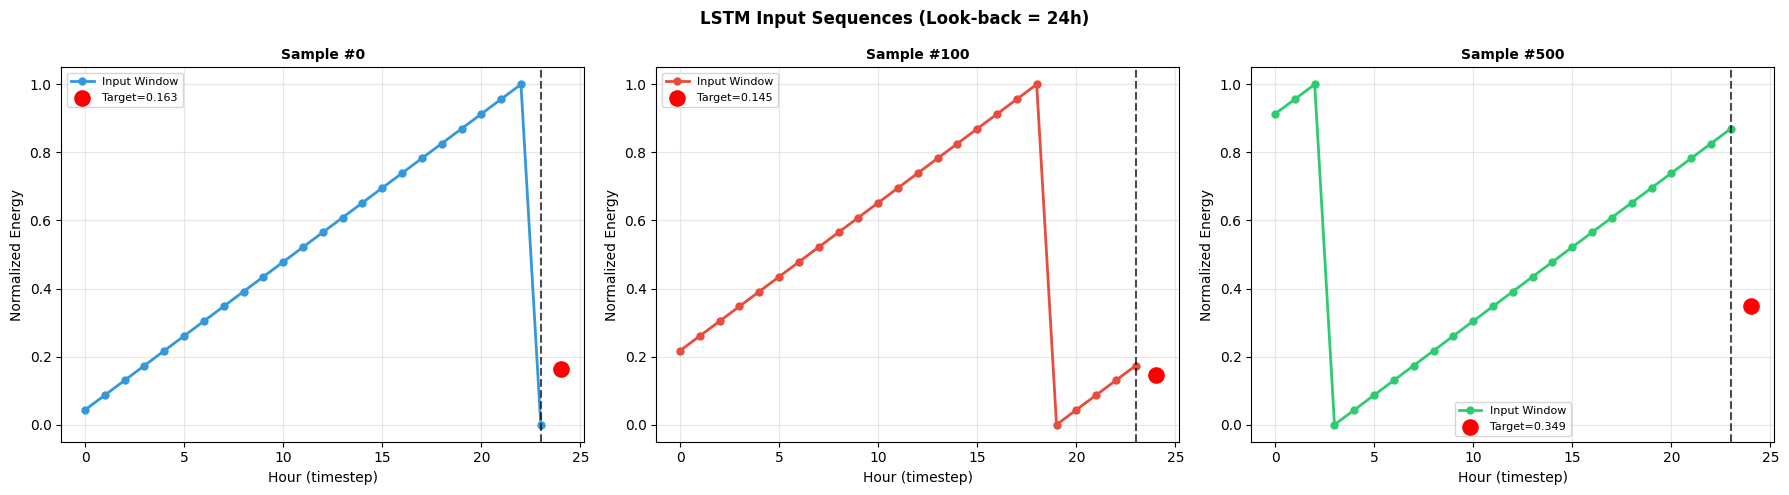

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'LSTM Input Sequences (Look-back = {SEQ_LEN}h)',
             fontsize=12, fontweight='bold')

colors_seq = ['#3498db', '#e74c3c', '#2ecc71']

for ax, sample_i, color in zip(axes, [0, 100, 500], colors_seq):
    seq    = X_seq[sample_i, :, 0]
    target = y_seq[sample_i]

    ax.plot(range(SEQ_LEN), seq,
            '-o', color=color, lw=2, ms=5,
            label='Input Window')
    ax.axvline(SEQ_LEN-1, color='black',
               ls='--', lw=1.5, alpha=0.7)
    ax.scatter(SEQ_LEN, target,
               color='red', s=120, zorder=5,
               label=f'Target={target:.3f}')
    ax.set_title(f'Sample #{sample_i}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Hour (timestep)')
    ax.set_ylabel('Normalized Energy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('06_sequence_windows.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
n_timesteps = X_train.shape[1]
n_features  = X_train.shape[2]

print(f"   Input : ({n_timesteps} timesteps × {n_features} features)")

def build_lstm_model(timesteps, features):
    inputs = keras.Input(
        shape=(timesteps, features),
        name='input_layer'
    )

    # ── LSTM Block 1 ──
    x = layers.LSTM(
        128,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.1,
        name='lstm_1'
    )(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)

    # ── LSTM Block 2 ──
    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.1,
        name='lstm_2'
    )(x)
    x = layers.BatchNormalization(name='bn_2')(x)

    # ── LSTM Block 3 ──
    x = layers.LSTM(
        32,
        return_sequences=False,
        dropout=0.15,
        name='lstm_3'
    )(x)
    x = layers.BatchNormalization(name='bn_3')(x)

    # ── Dense Head ──
    x = layers.Dense(64, activation='relu',
                     name='dense_1')(x)
    x = layers.Dropout(0.3, name='drop_1')(x)

    x = layers.Dense(32, activation='relu',
                     name='dense_2')(x)
    x = layers.Dropout(0.2, name='drop_2')(x)

    outputs = layers.Dense(1, name='output')(x)

    model = keras.Model(inputs, outputs, name='Energy_LSTM')
    return model

model = build_lstm_model(n_timesteps, n_features)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

model.summary()
print(f"\n✅ LSTM Model Built!")
print(f"   Architecture     : LSTM(128)→LSTM(64)→LSTM(32)→Dense")
print(f"   Total Parameters : {model.count_params():,}")

   Input : (24 timesteps × 38 features)


Model: "Energy_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 38)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        85,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 24, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 24, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,449 (595.50 KB)

 Trainable params: 152,001 (593.75 KB)

 Non-trainable params: 448 (1.75 KB)


✅ LSTM Model Built!
   Architecture     : LSTM(128)→LSTM(64)→LSTM(32)→Dense
   Total Parameters : 152,449


In [ ]:
layer_data = []
for layer in model.layers:
    layer_data.append({
        'Layer Name'   : layer.name,
        'Type'         : type(layer).__name__,
        'Output Shape' : str(layer.output_shape),
        'Parameters'   : f"{layer.count_params():,}"
    })

df_arch = pd.DataFrame(layer_data)

fig, ax = plt.subplots(figsize=(14, len(df_arch)*0.55+1.5))
ax.axis('off')

table = ax.table(
    cellText  = df_arch.values,
    colLabels = df_arch.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Header
for j in range(len(df_arch.columns)):
    table[(0,j)].set_facecolor('#1a5276')
    table[(0,j)].set_text_props(color='white', fontweight='bold')

# Row colors
color_map = {
    'LSTM'      : '#d6eaf8',
    'BatchNorm' : '#fef9e7',
    'Dense'     : '#d5f5e3',
    'Dropout'   : '#fde8d8',
}
for i in range(1, len(df_arch)+1):
    rtype = df_arch.iloc[i-1]['Type']
    bg    = '#f2f3f4'
    for key, col in color_map.items():
        if key.lower() in rtype.lower():
            bg = col
            break
    for j in range(len(df_arch.columns)):
        table[(i,j)].set_facecolor(bg)

plt.title(f'LSTM Architecture — Total Params: {model.count_params():,}',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('07_model_architecture.png', dpi=120, bbox_inches='tight')
plt.show()

AttributeError: 'InputLayer' object has no attribute 'output_shape'

In [ ]:
callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_lstm_model.keras',
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

print("  Epochs     : 5 (EarlyStopping)")
print("  Batch Size : 64")
print("  Optimizer  : Adam (lr=0.001)")
print("  Loss       : MSE\n")

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 5,
    batch_size      = 64,
    callbacks       = callbacks,
    verbose         = 1
)

best_ep       = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])

print(f"\n✅ Training Complete!")
print(f"   Best Val Loss : {best_val_loss:.6f}")
print(f"   Best Epoch    : {best_ep}")

  Epochs     : 5 (EarlyStopping)
  Batch Size : 64
  Optimizer  : Adam (lr=0.001)
  Loss       : MSE

Epoch 1/5
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.0746 - mae: 0.1877
Epoch 1: val_loss improved from None to 0.00661, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 241s 172ms/step - loss: 0.0319 - mae: 0.1262 - val_loss: 0.0066 - val_mae: 0.0653 - learning_rate: 0.0010
Epoch 2/5
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.0085 - mae: 0.0724
Epoch 2: val_loss improved from 0.00661 to 0.00281, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 215s 163ms/step - loss: 0.0073 - mae: 0.0669 - val_loss: 0.0028 - val_mae: 0.0431 - learning_rate: 0.0010
Epoch 3/5
1325/1325 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0052 - mae: 0.0558
Epoch 3: val_loss improved from 0.00281 to 0.00153, saving model to best_lstm_mod

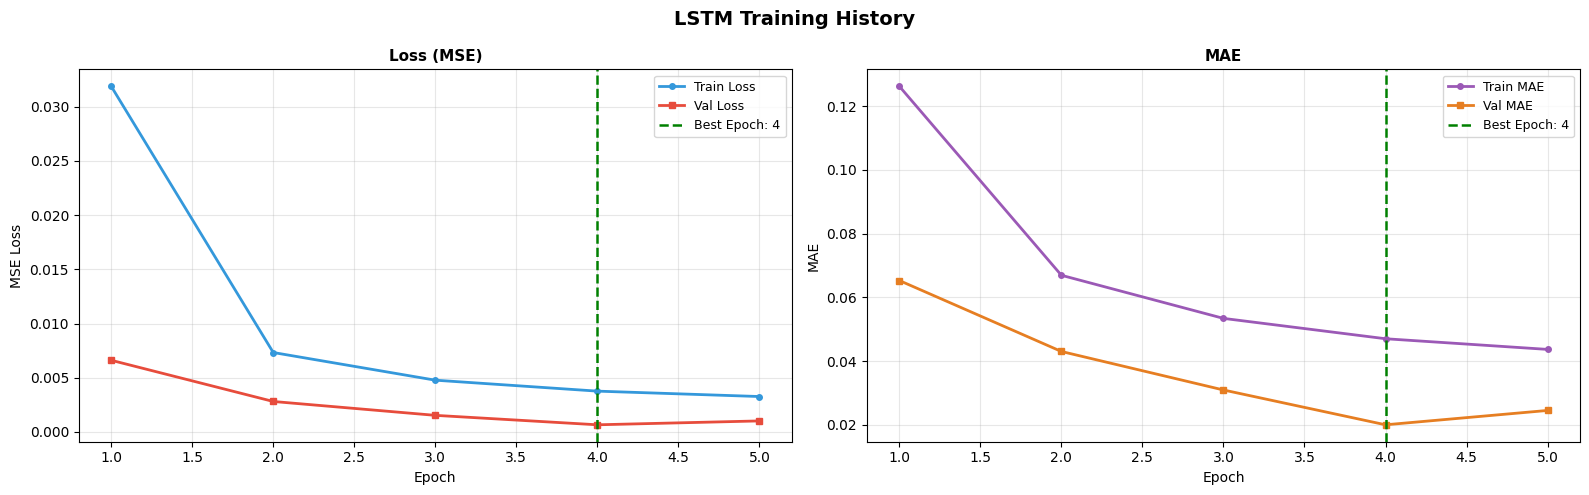

In [ ]:
ep = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(ep, history.history['loss'],
             '-o', color='#3498db', lw=2,
             ms=4, label='Train Loss')
axes[0].plot(ep, history.history['val_loss'],
             '-s', color='#e74c3c', lw=2,
             ms=4, label='Val Loss')
axes[0].axvline(best_ep, color='green', ls='--',
                lw=1.8, label=f'Best Epoch: {best_ep}')
axes[0].set_title('Loss (MSE)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(ep, history.history['mae'],
             '-o', color='#9b59b6', lw=2,
             ms=4, label='Train MAE')
axes[1].plot(ep, history.history['val_mae'],
             '-s', color='#e67e22', lw=2,
             ms=4, label='Val MAE')
axes[1].axvline(best_ep, color='green', ls='--',
                lw=1.8, label=f'Best Epoch: {best_ep}')
axes[1].set_title('MAE', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('08_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
best_model = load_model('best_lstm_model.keras')

# Inverse transform helper
def inverse(arr):
    return scaler_y.inverse_transform(
        arr.reshape(-1,1)).flatten()

# Predictions
y_pred_train = inverse(best_model.predict(X_train, verbose=0).flatten())
y_pred_val   = inverse(best_model.predict(X_val,   verbose=0).flatten())
y_pred_test  = inverse(best_model.predict(X_test,  verbose=0).flatten())

y_train_orig = inverse(y_train)
y_val_orig   = inverse(y_val)
y_test_orig  = inverse(y_test)

# Metrics
def get_metrics(true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    r2   = r2_score(true, pred)
    mape = np.mean(np.abs((true-pred)/(true+1e-8)))*100
    return {'RMSE':rmse,'MAE':mae,'R2':r2,'MAPE%':mape}

results = {
    'Train': get_metrics(y_train_orig, y_pred_train),
    'Val'  : get_metrics(y_val_orig,   y_pred_val),
    'Test' : get_metrics(y_test_orig,  y_pred_test),
}

print(f"\n{'Metric':<10}", end='')
for name in results:
    print(f"{name:>12}", end='')
print()
print("=" * 46)
for metric in ['RMSE','MAE','R2','MAPE%']:
    print(f"{metric:<10}", end='')
    for name in results:
        print(f"{results[name][metric]:>12.4f}", end='')
    print()

print(f"\n📊 Test Results:")
print(f"   RMSE  : {results['Test']['RMSE']:.4f} MW")
print(f"   MAE   : {results['Test']['MAE']:.4f} MW")
print(f"   R²    : {results['Test']['R2']:.4f}")
print(f"   MAPE  : {results['Test']['MAPE%']:.2f}%")

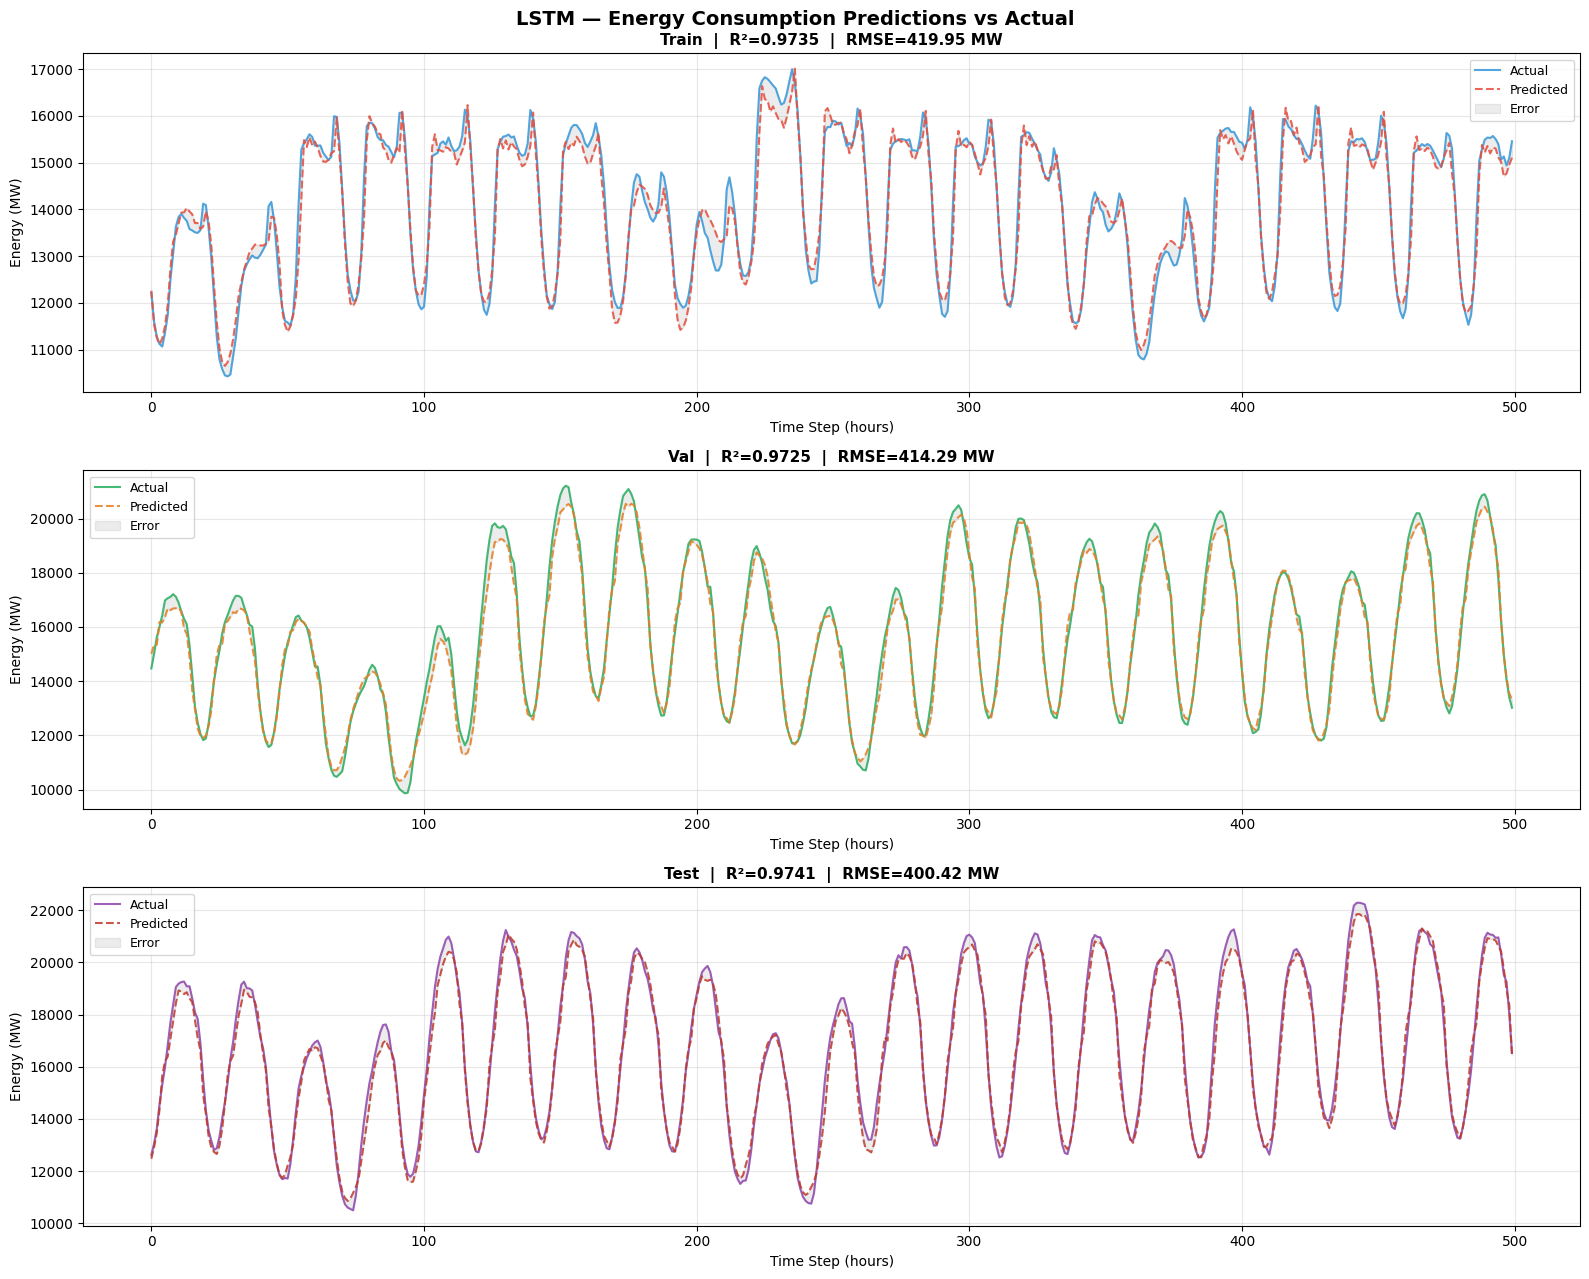

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('LSTM — Energy Consumption Predictions vs Actual',
             fontsize=14, fontweight='bold')

sets = [
    (y_train_orig, y_pred_train, 'Train', '#3498db', '#e74c3c'),
    (y_val_orig,   y_pred_val,   'Val',   '#27ae60', '#e67e22'),
    (y_test_orig,  y_pred_test,  'Test',  '#8e44ad', '#c0392b'),
]

for ax, (actual, pred, title, c1, c2) in zip(axes, sets):
    # Show only first 500 points for clarity
    n_show = min(500, len(actual))
    ax.plot(actual[:n_show], color=c1, lw=1.5,
            alpha=0.85, label='Actual')
    ax.plot(pred[:n_show],   color=c2, lw=1.5,
            alpha=0.85, ls='--', label='Predicted')
    ax.fill_between(range(n_show),
                    actual[:n_show], pred[:n_show],
                    alpha=0.15, color='gray',
                    label='Error')
    r2   = r2_score(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    ax.set_title(
        f'{title}  |  R²={r2:.4f}  |  RMSE={rmse:.2f} MW',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Step (hours)')
    ax.set_ylabel('Energy (MW)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

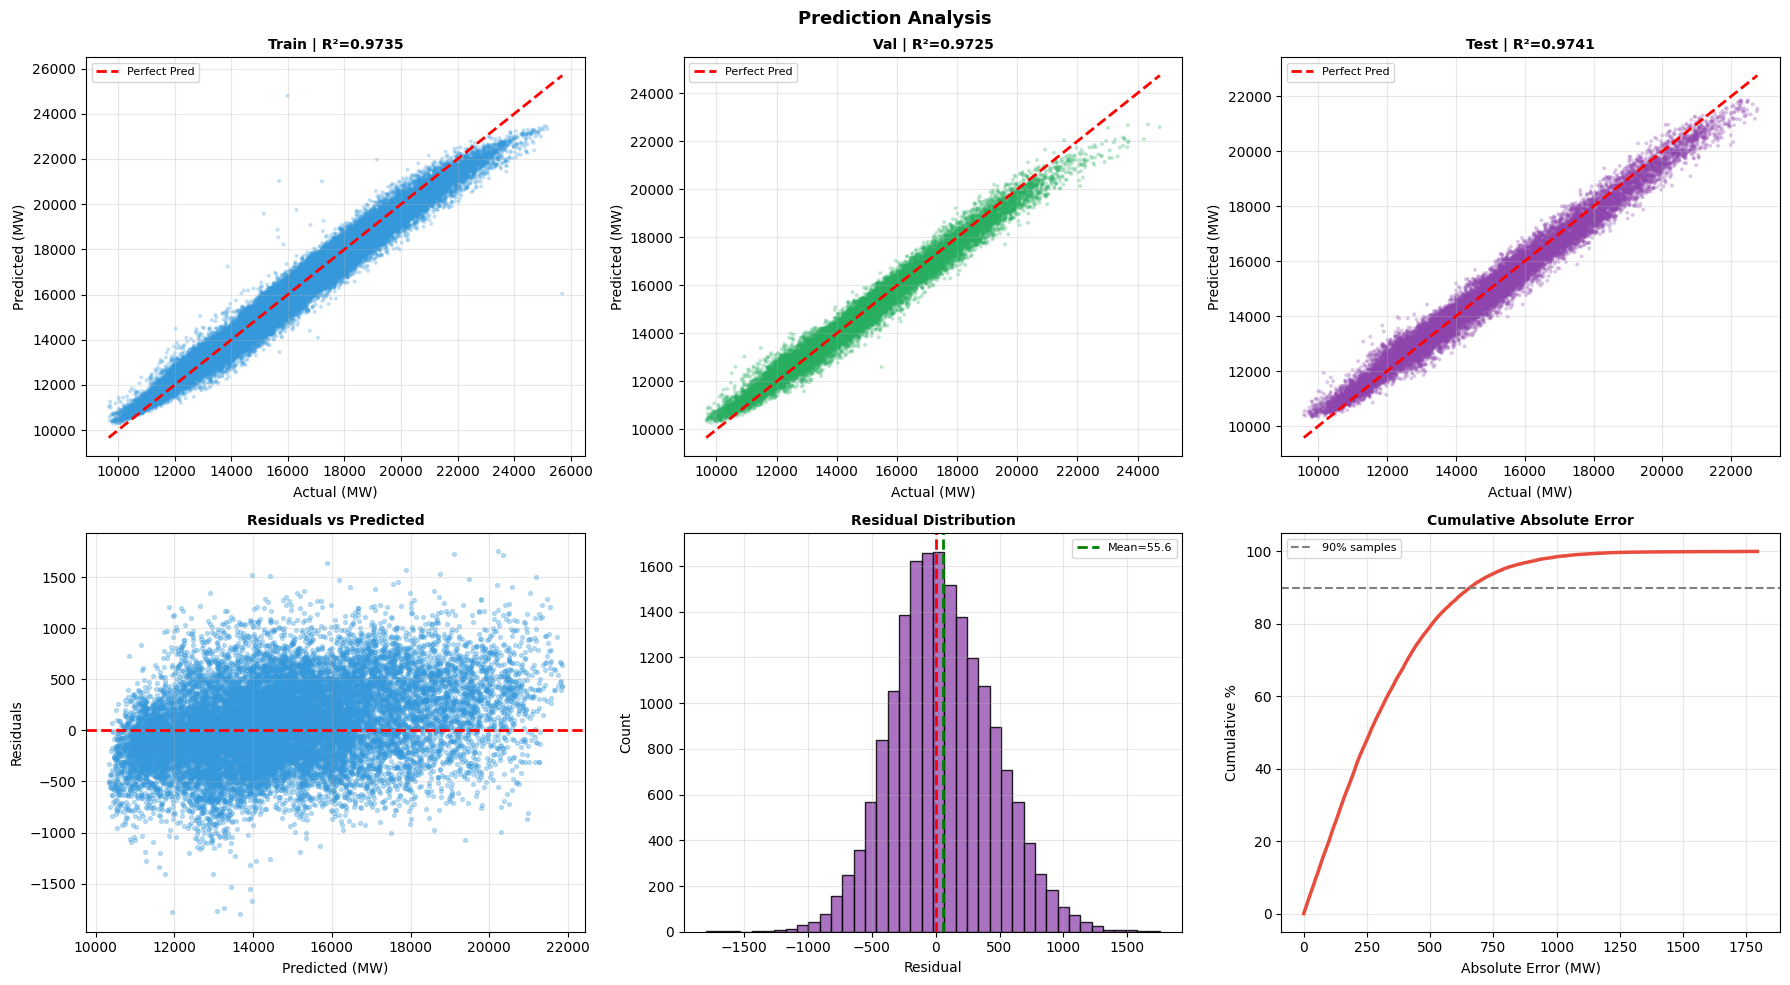

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prediction Analysis',
             fontsize=13, fontweight='bold')

sets2 = [
    (y_train_orig, y_pred_train, 'Train', '#3498db'),
    (y_val_orig,   y_pred_val,   'Val',   '#27ae60'),
    (y_test_orig,  y_pred_test,  'Test',  '#8e44ad'),
]

# Row 1: Scatter
for ax, (actual, pred, title, color) in zip(axes[0], sets2):
    ax.scatter(actual, pred, color=color,
               alpha=0.3, s=8, edgecolors='none')
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    ax.plot([mn,mx],[mn,mx],'r--', lw=2,
            label='Perfect Pred')
    r2 = r2_score(actual, pred)
    ax.set_title(f'{title} | R²={r2:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (MW)')
    ax.set_ylabel('Predicted (MW)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Row 2: Residuals
residuals = y_test_orig - y_pred_test

axes[1][0].scatter(y_pred_test, residuals,
                   color='#3498db', alpha=0.3, s=8)
axes[1][0].axhline(0, color='red', ls='--', lw=2)
axes[1][0].set_title('Residuals vs Predicted',
                     fontsize=10, fontweight='bold')
axes[1][0].set_xlabel('Predicted (MW)')
axes[1][0].set_ylabel('Residuals')
axes[1][0].grid(alpha=0.3)

axes[1][1].hist(residuals, bins=40,
                color='#9b59b6', edgecolor='black',
                lw=0.4, alpha=0.85)
axes[1][1].axvline(0, color='red', ls='--', lw=2)
axes[1][1].axvline(residuals.mean(), color='green',
                   ls='--', lw=2,
                   label=f'Mean={residuals.mean():.1f}')
axes[1][1].set_title('Residual Distribution',
                     fontsize=10, fontweight='bold')
axes[1][1].set_xlabel('Residual')
axes[1][1].set_ylabel('Count')
axes[1][1].legend(fontsize=8)
axes[1][1].grid(alpha=0.3)

sorted_res = np.sort(np.abs(residuals))
cum_pct    = np.arange(1, len(sorted_res)+1) / len(sorted_res)*100
axes[1][2].plot(sorted_res, cum_pct,
                color='#e74c3c', lw=2.5)
axes[1][2].axhline(90, color='gray', ls='--', lw=1.5,
                   label='90% samples')
axes[1][2].set_title('Cumulative Absolute Error',
                     fontsize=10, fontweight='bold')
axes[1][2].set_xlabel('Absolute Error (MW)')
axes[1][2].set_ylabel('Cumulative %')
axes[1][2].legend(fontsize=8)
axes[1][2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('10_prediction_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

In [40]:
best_model.save('energy_lstm_model.keras')
print("✅ energy_lstm_model.keras")

best_model.save('energy_lstm_model.h5')
print("✅ energy_lstm_model.h5")

best_model.save_weights('energy_lstm_weights.weights.h5')
print("✅ energy_lstm_weights.weights.h5")

with open('energy_lstm_architecture.json', 'w') as f:
    f.write(best_model.to_json())
print("✅ energy_lstm_architecture.json")

with open('scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_X': scaler_X,
                 'scaler_y': scaler_y}, f)
print("✅ scalers.pkl")

info = {
    "model"        : "Energy_LSTM",
    "dataset"      : "Hourly Energy Consumption",
    "kaggle"       : "robikscube/hourly-energy-consumption",
    "date"         : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "architecture" : "LSTM(128)→LSTM(64)→LSTM(32)→Dense(64)→Dense(32)",
    "task"         : "Time Series Regression (Energy Forecasting)",
    "seq_length"   : SEQ_LEN,
    "n_features"   : int(n_features),
    "feature_cols" : feature_cols,
    "test_rmse"    : round(float(results['Test']['RMSE']), 4),
    "test_mae"     : round(float(results['Test']['MAE']),  4),
    "test_r2"      : round(float(results['Test']['R2']),   4),
    "test_mape"    : round(float(results['Test']['MAPE%']),2),
    "total_params" : int(best_model.count_params()),
    "best_epoch"   : int(best_ep),
}
with open('model_info.json', 'w') as f:
    json.dump(info, f, indent=2)
print("✅ model_info.json")

✅ energy_lstm_model.keras
✅ energy_lstm_model.h5
✅ energy_lstm_weights.weights.h5
✅ energy_lstm_architecture.json
✅ scalers.pkl
✅ model_info.json


In [39]:
all_files = [
    'energy_lstm_model.keras',
    'energy_lstm_model.h5',
    'energy_lstm_weights.weights.h5',
    'energy_lstm_architecture.json',
    'scalers.pkl',
    'model_info.json',
    '01_timeseries.png',
    '02_seasonal_patterns.png',
    '03_distribution_analysis.png',
    '04_correlation_heatmap.png',
    '05_data_split.png',
    '06_sequence_windows.png',
    '07_model_architecture.png',
    '08_training_history.png',
    '09_predictions.png',
    '10_prediction_analysis.png',
]

zip_name = 'energy_lstm_complete.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"   Added : {f}")

zip_mb = os.path.getsize(zip_name) / (1024*1024)
print(f"\n📦 ZIP: {zip_name}  ({zip_mb:.1f} MB)")

try:
    from google.colab import files
    print("\n📥 Colab Download Starting...")
    files.download(zip_name)
    files.download('energy_lstm_model.h5')
    print("✅ Download Started!")
except ImportError:
    print("\n💡 Local — Files saved in current folder")
    for f in all_files:
        if os.path.exists(f):
            kb = os.path.getsize(f)/1024
            print(f"   📄 {f:<45} ({kb:.0f} KB)")

   Added : energy_lstm_model.keras
   Added : energy_lstm_model.h5
   Added : energy_lstm_weights.weights.h5
   Added : energy_lstm_architecture.json
   Added : scalers.pkl
   Added : model_info.json
   Added : 01_timeseries.png
   Added : 02_seasonal_patterns.png
   Added : 03_distribution_analysis.png
   Added : 04_correlation_heatmap.png
   Added : 05_data_split.png
   Added : 06_sequence_windows.png
   Added : 08_training_history.png
   Added : 09_predictions.png
   Added : 10_prediction_analysis.png

📦 ZIP: energy_lstm_complete.zip  (6.8 MB)

📥 Colab Download Starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download Started!


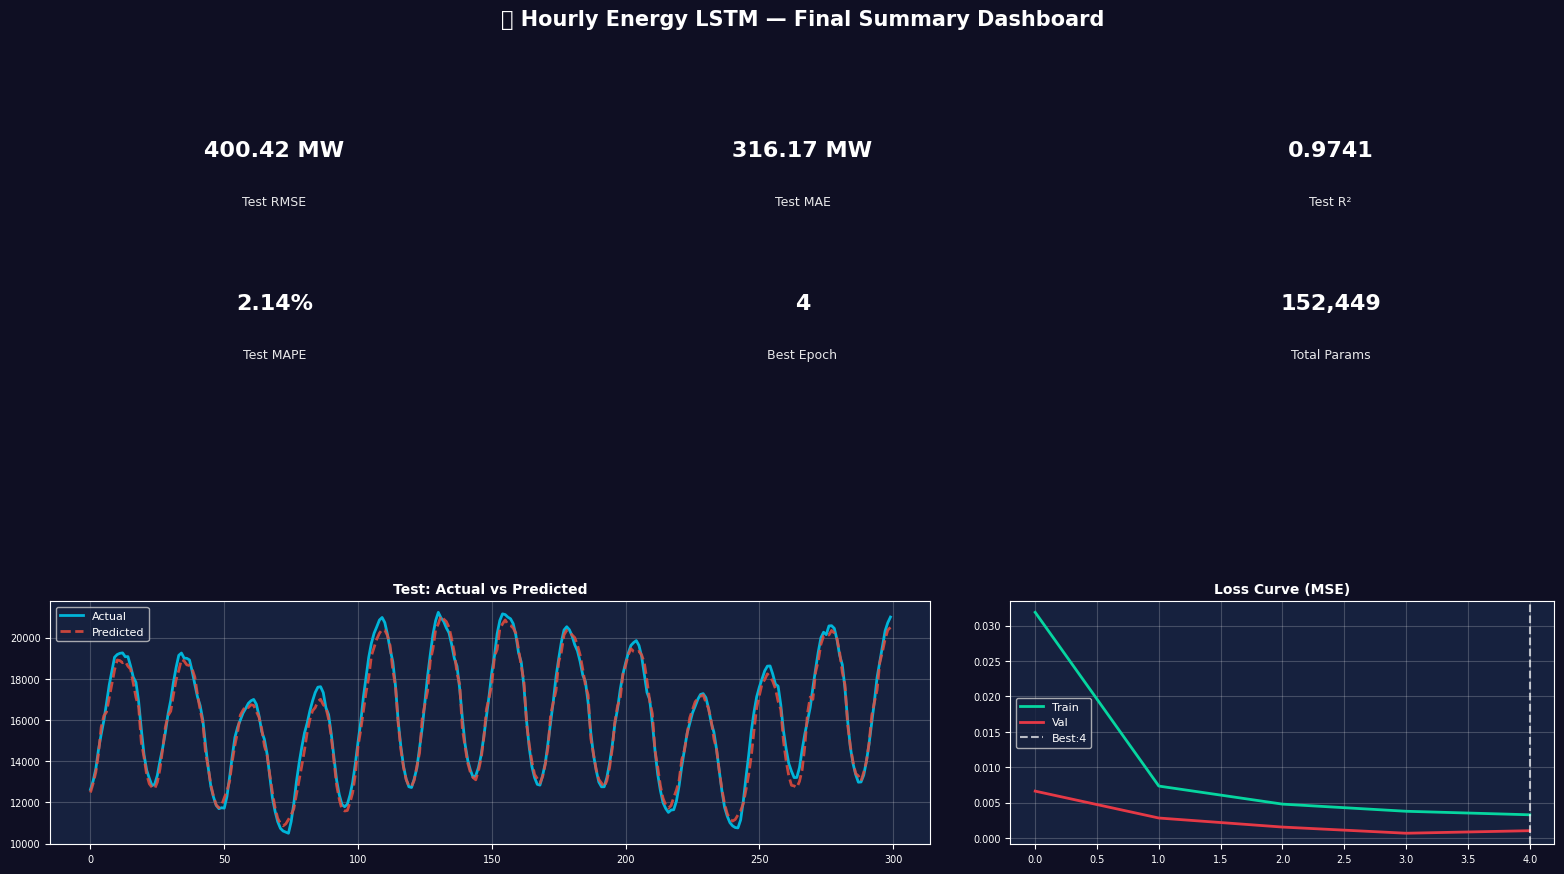

In [38]:
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0f0f23')

fig.text(0.5, 0.96,
         '🏆 Hourly Energy LSTM — Final Summary Dashboard',
         ha='center', fontsize=15,
         fontweight='bold', color='white')

# ── Metric Cards ──
test_rmse = results['Test']['RMSE']
test_mae  = results['Test']['MAE']
test_r2   = results['Test']['R2']
test_mape = results['Test']['MAPE%']

cards = [
    ('Test RMSE',    f'{test_rmse:.2f} MW',           '#e74c3c'),
    ('Test MAE',     f'{test_mae:.2f} MW',            '#e67e22'),
    ('Test R²',      f'{test_r2:.4f}',                '#06d6a0'),
    ('Test MAPE',    f'{test_mape:.2f}%',             '#ffd166'),
    ('Best Epoch',   f'{best_ep}',                    '#a8dadc'),
    ('Total Params', f'{best_model.count_params():,}','#f4a261'),
]

for i, (label, value, color) in enumerate(cards):
    ax = fig.add_axes(
        [0.03+(i%3)*0.33, 0.74-(i//3)*0.17, 0.28, 0.13]
    )
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.axis('off')

# ── Prediction Curve ──
ax_pred = fig.add_axes([0.03, 0.05, 0.55, 0.27])
ax_pred.set_facecolor('#16213e')
n_show = min(300, len(y_test_orig))
ax_pred.plot(y_test_orig[:n_show],
             color='#00b4d8', lw=2, label='Actual')
ax_pred.plot(y_pred_test[:n_show],
             color='#e74c3c', lw=2,
             ls='--', label='Predicted', alpha=0.85)
ax_pred.set_title('Test: Actual vs Predicted',
                  color='white', fontsize=10, fontweight='bold')
ax_pred.tick_params(colors='white', labelsize=7)
ax_pred.legend(fontsize=8, facecolor='#16213e', labelcolor='white')
ax_pred.grid(alpha=0.2, color='white')
for sp in ax_pred.spines.values():
    sp.set_color('white')

# ── Loss Curve ──
ax_loss = fig.add_axes([0.63, 0.05, 0.34, 0.27])
ax_loss.set_facecolor('#16213e')
ax_loss.plot(history.history['loss'],
             color='#06d6a0', lw=2, label='Train')
ax_loss.plot(history.history['val_loss'],
             color='#e63946', lw=2, label='Val')
ax_loss.axvline(best_ep, color='white', ls='--',
                lw=1.5, alpha=0.7,
                label=f'Best:{best_ep}')
ax_loss.set_title('Loss Curve (MSE)',
                  color='white', fontsize=10, fontweight='bold')
ax_loss.tick_params(colors='white', labelsize=7)
ax_loss.legend(fontsize=8,
               facecolor='#16213e', labelcolor='white')
ax_loss.grid(alpha=0.2, color='white')
for sp in ax_loss.spines.values():
    sp.set_color('white')

plt.savefig('11_final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f23')
plt.show()

In [37]:
print(f"  Dataset      : Hourly Energy Consumption (Kaggle)")
print(f"  KaggleHub    : robikscube/hourly-energy-consumption")
print(f"  Task         : Time Series Regression")
print(f"  Architecture : LSTM(128)→LSTM(64)→LSTM(32)→Dense")
print(f"  Seq Length   : {SEQ_LEN} hours look-back")
print(f"  Test RMSE    : {test_rmse:.4f} MW")
print(f"  Test R²      : {test_r2:.4f}")
print(f"  Test MAPE    : {test_mape:.2f}%")
print(f"  Model Saved  : .keras | .h5 | weights | json | scalers")


  Dataset      : Hourly Energy Consumption (Kaggle)
  KaggleHub    : robikscube/hourly-energy-consumption
  Task         : Time Series Regression
  Architecture : LSTM(128)→LSTM(64)→LSTM(32)→Dense
  Seq Length   : 24 hours look-back
  Test RMSE    : 400.4205 MW
  Test R²      : 0.9741
  Test MAPE    : 2.14%
  Model Saved  : .keras | .h5 | weights | json | scalers
